In [1]:
import torch
import torch.nn as nn
import torchvision
import numpy as np
from matplotlib import pyplot as plt

from model.classifier import Classifier, MyProgressBar
from utils.transforms.apply import grid_resample

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from its.transform import multi_transform
from utils.affine_transforms import AffineTransformation2D
from dataset.mnist_no_pil import NoPILMNIST, NoPILFashionMNIST, AffineTransformDataset

dataset = 'mnist' # or 'fmnist'
batch_size = 128
#divide by 255 transform


if dataset == 'mnist':
    # essentially excluding either 6 or 9 as these would cause degenerations under 180 degree rotation
    dataset_train = NoPILMNIST("../experiment_files/data",train=True,download=True)
    n_classes = 10
    dataset_val_test = NoPILMNIST("../experiment_files/data",train=False,download=True)
    #split into validation and test set
    dataset_val, dataset_test_pre = #fix this, use val from train as this is what is usually expected.
elif dataset == 'fmnist':
    dataset_train = NoPILFashionMNIST("../experiment_files/data",train=True,download=True)
    n_classes = 10
    dataset_val_test = NoPILFashionMNIST("../experiment_files/data",train=False,download=True)
    #split into validation and test set
    dataset_val, dataset_test_pre = #fix this, use val from train as this is what is usually expected.



transformations = [AffineTransformation2D.ROTATION.value,AffineTransformation2D.SHEARING_X.value,AffineTransformation2D.SHEARING_Y.value
                     ,AffineTransformation2D.SCALING_X.value,AffineTransformation2D.SCALING_Y.value]
domains = [(-torch.pi,torch.pi), ((-0.5, 0.5),), ((-0.5, 0.5),), ((1/1.3-1, 0.3),), ((1/1.3-1, 0.3),)]
n_samples = 17

def transform(batch_size):
    n = torch.randint(0, n_samples, (batch_size, len(transformations)), device="cpu")
    x_test = torch.zeros(batch_size, 1, 28, 28, device="cpu")
    _, _, T = multi_transform(x_test, transformations, n, n_samples=n_samples, domain=domains)
    return T


dataset_test = AffineTransformDataset(dataset_test_pre,transform,return_transformation=False,batch_size=batch_size)

dataset_train = AffineTransformDataset(dataset_train,transform,return_transformation=False,batch_size=batch_size)

dataset_val = AffineTransformDataset(dataset_val,transform,return_transformation=False,batch_size=batch_size)


In [3]:
train_loader = torch.utils.data.DataLoader(dataset_train, batch_size=batch_size, shuffle=True, num_workers=4,persistent_workers=True)
val_loader = torch.utils.data.DataLoader(dataset_val, batch_size=batch_size, shuffle=False, num_workers=4,persistent_workers=True)
test_loader = torch.utils.data.DataLoader(dataset_test, batch_size=batch_size, shuffle=False, num_workers=4,persistent_workers=True)

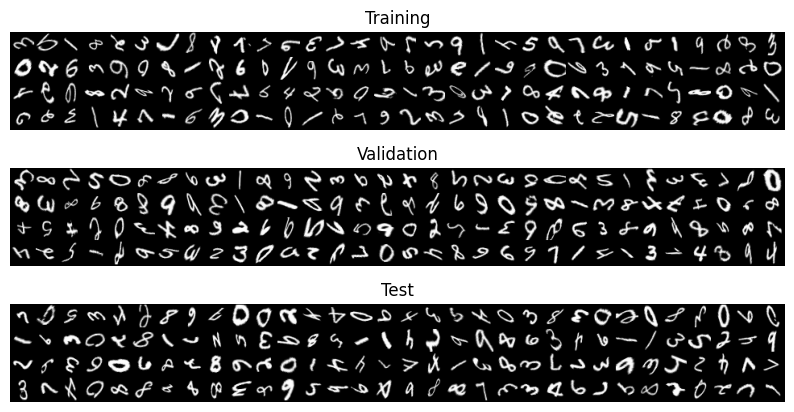

In [4]:
#test images
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(10, 5))

axs[0].imshow(torchvision.utils.make_grid(next(iter(train_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[1].imshow(torchvision.utils.make_grid(next(iter(val_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[2].imshow(torchvision.utils.make_grid(next(iter(test_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[0].set_title('Training')
axs[1].set_title('Validation')
axs[2].set_title('Test')

for ax in axs.flat:
    ax.axis('off')

In [6]:
import pytorch_lightning as pl
import os

model_path = f'../model/{dataset}_rot2.pth'

model = nn.Sequential(
    nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1),  # Output: 32x28x28
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 32x14x14
    nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),  # Output: 64x14x14
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 64x7x7
    nn.Flatten(),
    nn.Linear(64 * 7 * 7, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)


# Check if model is already trained
if os.path.exists(model_path):
    print(f"Loading model from {model_path}")
    model.load_state_dict(torch.load(model_path))
else:
    print(f"Training model and will save to {model_path}")
    lightning_model = Classifier(model, optimizer_class =  torch.optim.AdamW, optimizer_params = {"lr": 1e-3})
    progress_bar = MyProgressBar()
    trainer = pl.Trainer(
        accelerator="cuda",
        max_epochs=20,
        precision="16-mixed",
        callbacks=[progress_bar],
    )
    # Train the model
    trainer.fit(lightning_model, train_loader,val_loader)
    # Test the model
    #trainer.test(lightning_model, test_loader)
    # Save model
    torch.save(model.state_dict(), model_path)
    print(f"Model saved to {model_path}")

Using 16bit Automatic Mixed Precision (AMP)
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type       | Params | Mode 
---------------------------------------------
0 | model | Sequential | 440 K  | train
---------------------------------------------
440 K     Trainable params
0         Non-trainable params
440 K     Total params
1.762     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode


Training model and will save to ../model/mnist_rot2.pth
Epoch 19: 100%|██████████| 469/469 [00:04<00:00, 113.48it/s, v_num=141, val_loss=0.292, val_acc=0.938]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 469/469 [00:04<00:00, 113.04it/s, v_num=141, val_loss=0.292, val_acc=0.938]
Model saved to ../model/mnist_rot2.pth


In [7]:
#calibrate the model
#from confidence.calibration import TemperatureCalibrationModule
#if model is not temperature calibrated
#if isinstance(model, TemperatureCalibrationModule):
    #model = model.model
#model = TemperatureCalibrationModule(model,per_logit=True).cuda()
#model.fit(test_loader)


In [8]:
model.cuda()

Sequential(
  (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=3136, out_features=128, bias=True)
  (8): ReLU()
  (9): Linear(in_features=128, out_features=10, bias=True)
)

In [9]:
with torch.no_grad():
    model.eval()
    test_acc = 0
    for data, target in val_loader:
        data, target = data.cuda(), target.cuda()
        output = model(data)
        test_acc += output.argmax(dim=-1).eq(target).sum().item()
    test_acc /= len(dataset_val)
    print(f'Mean accuracy on the val set: {test_acc}.')

Mean accuracy on the val set: 0.938.


In [10]:
with torch.no_grad():
    model.eval()
    test_acc = 0
    for data, target in test_loader:
        data, target = data.cuda(), target.cuda()
        output = model(data)
        test_acc += output.argmax(dim=-1).eq(target).sum().item()
    test_acc /= len(dataset_test)
    print(f'Mean accuracy on the transformed test set: {test_acc}.')

Mean accuracy on the transformed test set: 0.9336.


In [12]:

from confidence.base_confidence import EnergyConfidence, SinglePassConfidence
from its.search import InverseTransformationSearch
confidence_module = SinglePassConfidence(model, EnergyConfidence())
its = InverseTransformationSearch(model, transformation=transformations, domain=domains,
                                  n_samples=17, n_hypotheses=1, mc_steps=1,
                                  change_of_mind='score', en_unique_class_condition=True,gaussian_filter_channel_wise=False,confidence_module=confidence_module)



with torch.no_grad():
    model.eval()
    test_acc = 0
    for d, (data, target) in enumerate(test_loader):
        data, target = data.cuda(), target.cuda()
        data_canonic, embedding = its.infer(data, plot_idx=None)
        # pick the class of the leading hypothesis
        output = embedding.argmax(dim=-1)[:, 0]
        test_acc += output.eq(target).sum().item()
    test_acc /= len(dataset_test)
    print(f'Mean accuracy on the transformed test set [but with ITS]: {test_acc}.')

RuntimeError: Expected 3D (unbatched) or 4D (batched) input to conv2d, but got input of size: [128, 1, 17, 1, 28, 28]

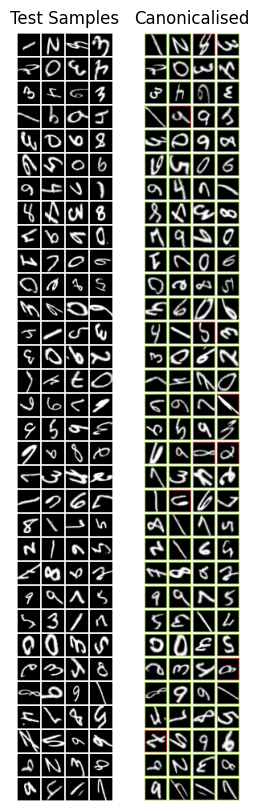

In [11]:
data, target = next(iter(test_loader))
data_canonic, embedding = its.infer(data.cuda())
output = embedding.argmax(dim=-1)[:, 0]
correct_label = output.eq(target.cuda())

# highlight correct predictions with green frame
green = torch.tensor((143, 194, 62))[:, None] / 255.
red = torch.tensor((194, 80, 62))[:, None] / 255.
data_canonic = data_canonic[:, 0].repeat(1, 3, 1, 1)
for image, correct in zip(data_canonic, correct_label):
    color = green if correct else red
    image[:, :, 0] = color
    image[:, :, 27] = color
    image[:, 0, :] = color
    image[:, 27, :] = color

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(3, 10))

axs[0].imshow(torchvision.utils.make_grid(data.cpu(), nrow=4, pad_value=1).permute(1, 2, 0), cmap='gray')
axs[1].imshow(torchvision.utils.make_grid(data_canonic.cpu(), nrow=4, pad_value=1).permute(1, 2, 0))

axs[0].set_title('Test Samples')
axs[1].set_title('Canonicalised')

for ax in axs.flat:
    ax.axis('off')

In [12]:
#test simulated annealing
from utils.transformation_problem import TransformationProblem
from utils.transform_sequence import TransformSequence
transform_seq= TransformSequence(transformations, domains, neighbour_hood_size =0.25,application_method=grid_resample,device=device,reflect=False,use_individual_param_correction=False)

transformation_problem = TransformationProblem(confidence_module,transform_seq,consolidate_method="consolidate_simple")

transformation_problem2 = TransformationProblem(confidence_module,transform_seq,consolidate_method="consolidate_simple")


In [13]:
from search.simulated_anealing import ParallelSimulatedAnnealing

sim = ParallelSimulatedAnnealing(max_iterations=5,parallel_runs=20,initial_temp=0)
x = next(iter(test_loader))[0].cuda()

Iteration 1/5, Temperature: 0.0000, Mean Best Error: -7.1935,Current Error: -7.1935
Iteration 2/5, Temperature: 0.0000, Mean Best Error: -7.4855,Current Error: -7.4855
Iteration 3/5, Temperature: 0.0000, Mean Best Error: -7.7265,Current Error: -7.7265
Iteration 4/5, Temperature: 0.0000, Mean Best Error: -7.9429,Current Error: -7.9429
Iteration 5/5, Temperature: 0.0000, Mean Best Error: -8.1421,Current Error: -8.1421


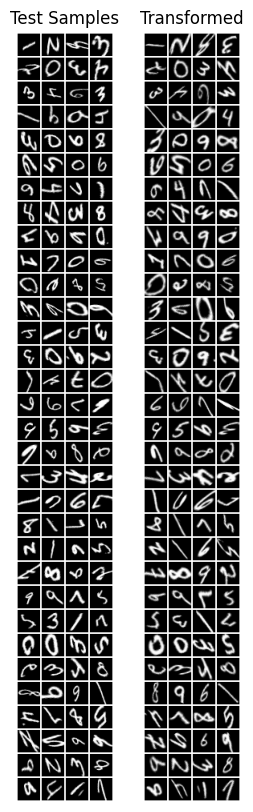

In [14]:
T = sim.optimize(transformation_problem,x.cuda(),verbose=True)

x_transfomred = transformation_problem.transform(x.cuda(),T[0])
#plot them next to each other
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(3, 10))
axs[0].imshow(torchvision.utils.make_grid(x.cpu(), nrow=4, pad_value=1).permute(1, 2, 0), cmap='gray')
axs[1].imshow(torchvision.utils.make_grid(x_transfomred.cpu(), nrow=4, pad_value=1).permute(1, 2, 0), cmap='gray')
axs[0].set_title('Test Samples')
axs[1].set_title('Transformed')
for ax in axs.flat:
    ax.axis('off')

plt.show()

In [15]:
#aaply to whole
test_acc_sim = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = sim.optimize(transformation_problem,data.cuda())
    #pick the class of the leading hypothesis
    x_transfomred = transformation_problem.transform(data.cuda(),res[0])
    logits = model(x_transfomred)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()

test_acc_sim /= len(dataset_test)

print(f'Mean accuracy on the transformed test set with Simulated Annealing: {test_acc_sim}.')





Mean accuracy on the transformed test set with Simulated Annealing: 0.9226.


In [16]:
#aaply to whole
test_acc_sim = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = sim.optimize(transformation_problem2,data.cuda())
    #pick the class of the leading hypothesis
    x_transfomred = transformation_problem.transform(data.cuda(),res[0])
    logits = model(x_transfomred)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()

test_acc_sim /= len(dataset_test)

print(f'Mean accuracy on the transformed test set with Simulated Annealing: {test_acc_sim}.')





Mean accuracy on the transformed test set with Simulated Annealing: 0.9256.


In [17]:
list(model.named_modules())

[('',
  Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=3136, out_features=128, bias=True)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=10, bias=True)
  )),
 ('0', Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))),
 ('1', ReLU()),
 ('2',
  MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)),
 ('3', Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))),
 ('4', ReLU()),
 ('5',
  MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)),
 ('6', Flatten(start_dim=1, end_dim=-1)),
 ('7', Linear(in_features=3136, out_features=128

In [18]:
from confidence.utils import ModelInputWrapper

#use model wrapper to extract the embeddings
dual_ouput_model = ModelInputWrapper(model,'9',flatten=True)

In [19]:
#extract embeddings and fit NNDistanceConfidence()
embeddings=[]
classes =[]
for batch in train_loader:
    emb,_ = dual_ouput_model(batch[0].cuda())
    embeddings.append(emb.detach().cpu().numpy())
    classes.append(batch[1].detach().cpu().numpy())


embeddings = np.vstack(embeddings)
classes = np.hstack(classes)

#randomly sample 5000 ones
if embeddings.shape[0] > 5000:
    indices = np.random.choice(embeddings.shape[0], 5000, replace=False)
    embeddings = embeddings[indices]

In [20]:

from confidence.nn import NNDistanceConfidence
#test nearrest neigbhoor confidence
nearest_neighbor_confidence = NNDistanceConfidence(index_type="ivfpq",number_of_neighbors=3)
nearest_neighbor_confidence.fit(embeddings)
nearest_neighbor_confidence.cuda()

NNDistanceConfidence()

In [21]:
from confidence.base_confidence import SplitConfidence, SinglePassConfidence
conf_split = SplitConfidence(nearest_neighbor_confidence,EnergyConfidence(), mult=True,b=1.0)
conf_2 = SinglePassConfidence(dual_ouput_model,conf_split,index=1)
problem2 = TransformationProblem(conf_2, transform_seq, consolidate_method="consolidate_simple")

# Create a new SimulatedAnnealing instance for the second confidence measure
sim2 = ParallelSimulatedAnnealing(max_iterations=5, parallel_runs=30, initial_temp=0)

In [22]:
x = next(iter(test_loader))[0].to(device)
T2 = sim2.optimize(problem2, x.cuda(), verbose=True)

Iteration 1/5, Temperature: 0.0000, Mean Best Error: -0.0218,Current Error: -0.0218
Iteration 2/5, Temperature: 0.0000, Mean Best Error: -0.0230,Current Error: -0.0230
Iteration 3/5, Temperature: 0.0000, Mean Best Error: -0.0242,Current Error: -0.0242
Iteration 4/5, Temperature: 0.0000, Mean Best Error: -0.0251,Current Error: -0.0251
Iteration 5/5, Temperature: 0.0000, Mean Best Error: -0.0259,Current Error: -0.0259


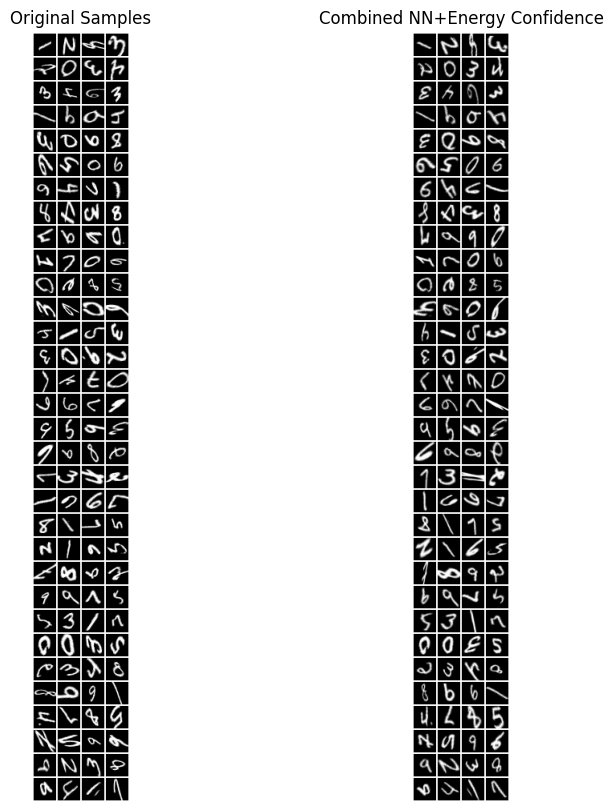

In [23]:
# Visualize the transformation results
x_transformed2 = problem2.transform(x.cuda(), T2[0])

# Plot them next to each other
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(9, 10))
axs[0].imshow(torchvision.utils.make_grid(x.cpu(), nrow=4, pad_value=1).permute(1, 2, 0), cmap='gray')
axs[1].imshow(torchvision.utils.make_grid(x_transformed2.cpu(), nrow=4, pad_value=1).permute(1, 2, 0), cmap='gray')

axs[0].set_title('Original Samples')
axs[1].set_title('Combined NN+Energy Confidence')

for ax in axs.flat:
    ax.axis('off')

plt.show()


In [24]:
# Run simulated annealing with the combined confidence measure on the whole test set
test_acc_sim = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = sim2.optimize(problem2, data.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem2.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()

test_acc_sim /= len(dataset_test)

print(f'Mean accuracy on the transformed test set with Simulated Annealing: {test_acc_sim}.')

Mean accuracy on the transformed test set with Simulated Annealing: 0.9138.


In [25]:
from search.parallel_gradient import ParallelGradientDescent
pd = ParallelGradientDescent(max_iterations=10, parallel_runs=10,learning_rate=1, lr_decay_rate = 1)

In [26]:
test_acc_sim = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = pd.optimize(problem2, data.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem2.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()

test_acc_sim /= len(dataset_test)

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.8904.


In [27]:
from search.parallel_gradient import ParallelGradientDescent

pd = ParallelGradientDescent(max_iterations=100, parallel_runs=1, learning_rate=1, lr_decay_rate=1)
test_acc_sim = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = pd.optimize(problem2, data.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem2.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()

test_acc_sim /= len(dataset_test)

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.8948.


In [28]:
from search.parallel_gradient import WindowStuckDetectionDescent

pd = WindowStuckDetectionDescent(max_iterations=100, parallel_runs=1, learning_rate=1, lr_decay_rate=1)
test_acc_sim = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = pd.optimize(problem2, data.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem2.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()

test_acc_sim /= len(dataset_test)

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.9142.


In [29]:
res = pd.optimize(problem2, data.cuda(),verbose=True)


Iter 1/100, LR:1.000000, Err:-0.0342, Best:-0.0342
Iter 5: Reinitialized 8 stuck runs                       (Δ<0.001, flat<0.0001, osc>0.6)
Iter 8: Reinitialized 5 stuck runs                       (Δ<0.001, flat<0.0001, osc>0.6)
Iter 9: Reinitialized 1 stuck runs                       (Δ<0.001, flat<0.0001, osc>0.6)
Iter 10: Reinitialized 1 stuck runs                       (Δ<0.001, flat<0.0001, osc>0.6)
Iter 11/100, LR:1.000000, Err:-0.0260, Best:-0.0424
Iter 12: Reinitialized 3 stuck runs                       (Δ<0.001, flat<0.0001, osc>0.6)
Iter 13: Reinitialized 2 stuck runs                       (Δ<0.001, flat<0.0001, osc>0.6)
Iter 14: Reinitialized 3 stuck runs                       (Δ<0.001, flat<0.0001, osc>0.6)
Iter 15: Reinitialized 1 stuck runs                       (Δ<0.001, flat<0.0001, osc>0.6)
Iter 16: Reinitialized 1 stuck runs                       (Δ<0.001, flat<0.0001, osc>0.6)
Iter 17: Reinitialized 3 stuck runs                       (Δ<0.001, flat<0.0001, osc>0.6)


In [30]:
pd.optimize(problem2, data.cuda())

(tensor([[ 2.3314, -0.5000,  0.3117, -0.2308,  0.3000],
         [-2.5453,  0.1107,  0.5000, -0.0648, -0.0536],
         [ 1.8255, -0.0257,  0.0101, -0.2308,  0.3000],
         [-1.5538,  0.4880,  0.5000,  0.2365, -0.2308],
         [-2.3857, -0.1917,  0.0938, -0.0903,  0.2500],
         [ 1.7124, -0.2503,  0.5000, -0.2303, -0.2308],
         [ 2.9358, -0.1903, -0.4484,  0.1599, -0.1488],
         [-2.0181,  0.5000, -0.5000,  0.3000,  0.3000]], device='cuda:0'),
 tensor([-0.0448, -0.0411, -0.0399, -0.0452, -0.0402, -0.1264, -0.0567, -0.0369],
        device='cuda:0'),
 tensor([[4],
         [6],
         [6],
         [9],
         [2],
         [1],
         [4],
         [3]], device='cuda:0'))

In [31]:
import search.shgo
import importlib
importlib.reload(search.shgo)

<module 'search.shgo' from 'C:\\Users\\Lindner\\PycharmProjects\\experiments_rotation\\search\\shgo.py'>

In [32]:
di = search.shgo.SHGO(selection_method="topk")

In [33]:
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem2, data.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem2.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.912.


In [34]:
import search.simulated_anealing
import importlib
importlib.reload(search.simulated_anealing)

<module 'search.simulated_anealing' from 'C:\\Users\\Lindner\\PycharmProjects\\experiments_rotation\\search\\simulated_anealing.py'>

In [35]:
da = search.simulated_anealing.DualAnnealing(reuse_optimizer=False,local_max_steps=0,max_iterations=4,parallel_runs=20,local_opt_kwargs={"lr":1e-1},initial_temp=0)

In [36]:
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = da.optimize(problem2, data.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem2.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]


test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.9186.


In [37]:
sim3 = ParallelSimulatedAnnealing(max_iterations=10, parallel_runs=10, initial_temp=0)


In [38]:
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = sim3.optimize(problem2, data.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem2.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]


test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.9134.


In [39]:
import search.evo
import importlib
importlib.reload(search.evo)

<module 'search.evo' from 'C:\\Users\\Lindner\\PycharmProjects\\experiments_rotation\\search\\evo.py'>

In [40]:
ea =search.evo.EvolutionaryAlgorithm(num_parallels=10,population_size_factor=2,num_generations=10,local_max_steps=2)

In [41]:
ea.optimize(problem2, data.cuda(),verbose=True)

Generation 1/10: Best error: -0.11076849699020386
Generation 2/10: Best error: -0.131074458360672
Generation 3/10: Best error: -0.131074458360672
Generation 4/10: Best error: -0.131074458360672
Generation 5/10: Best error: -0.131074458360672
Generation 6/10: Best error: -0.131074458360672
Generation 7/10: Best error: -0.131074458360672
Generation 8/10: Best error: -0.131074458360672
Generation 9/10: Best error: -0.131074458360672
Generation 10/10: Best error: -0.131074458360672


(tensor([[ 0.9253, -0.2251, -0.2440, -0.2308,  0.0303],
         [-2.3073,  0.5000,  0.3259, -0.0686,  0.0451],
         [ 1.7352, -0.2431,  0.1392,  0.0092,  0.3000],
         [ 2.6548,  0.4110,  0.0661,  0.3000, -0.1959],
         [ 0.3213, -0.5000,  0.1039, -0.0758,  0.3000],
         [-2.0813,  0.5000,  0.0837, -0.2308, -0.2289],
         [-1.9289,  0.0293, -0.3379, -0.1681,  0.2449],
         [-1.1702,  0.5000, -0.5000,  0.3000,  0.2731]], device='cuda:0'),
 tensor([-0.0503, -0.0384, -0.0443, -0.0542, -0.0469, -0.1311, -0.0486, -0.0449],
        device='cuda:0'),
 tensor([[4],
         [6],
         [6],
         [9],
         [2],
         [1],
         [4],
         [3]], device='cuda:0'))

In [42]:
torch.cuda.empty_cache()

In [43]:
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = ea.optimize(problem2, data.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem2.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]


test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.9154.
